# Parcial

In [ ]:
# utilizado para la manipulación de directorios y rutas
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Modulo de optimizacion en scipy
from scipy import optimize

# modulo para cargar archivos en formato MATLAB
# from scipy.io import loadmat

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [ ]:
# 1. Cargar el dataset (Asegúrate de tener train.csv en tu carpeta)
print("Cargando el dataset TPS Dec 2021 (Esto puede tardar un momento por su tamaño)...")
# Se utilizo el dataset de Kaggle "Tabular Playground Series - Dec 2021" que se encuentra en el archivo 'train.csv' 
#  https://www.kaggle.com/code/saraswatitiwari/tabular-playground-series-dec-2021/input
df_completo = pd.read_csv('train.csv')

# 2. Eliminar columna 'Id' que no es una característica matemática
if 'Id' in df_completo.columns:
    df_completo = df_completo.drop('Id', axis=1)

# 3. Limpieza Inteligente: Filtrar clases anómalas (muy pocos datos)
conteo = df_completo['Cover_Type'].value_counts()
clases_validas = conteo[conteo > 10000].index
df_limpio = df_completo[df_completo['Cover_Type'].isin(clases_validas)]

# 4. Balanceo del Dataset
min_ejemplos = df_limpio['Cover_Type'].value_counts().min()
print(f"Balanceando las clases restantes a {min_ejemplos} ejemplos cada una...")

df_balanceado = df_limpio.groupby('Cover_Type').sample(n=min_ejemplos, random_state=42).reset_index(drop=True)

# 5. Mezclar aleatoriamente (Shuffle)
df_mezclado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

# 6. División 80% Entrenamiento / 20% Prueba
limite = int(0.8 * len(df_mezclado))

df_train = df_mezclado.iloc[:limite]
df_test = df_mezclado.iloc[limite:]

X_train = df_train.drop('Cover_Type', axis=1).values.astype(float)
y_train_original = df_train['Cover_Type'].values.astype(int)

X_test = df_test.drop('Cover_Type', axis=1).values.astype(float)
y_test_original = df_test['Cover_Type'].values.astype(int)

# 7. Mapear etiquetas para que comiencen desde 0 (Requisito para el ciclo One-vs-All)
clases_unicas = np.unique(y_train_original)
num_labels = len(clases_unicas)
mapeo_clases = {val: idx for idx, val in enumerate(clases_unicas)}

y_train = np.vectorize(mapeo_clases.get)(y_train_original)
y_test = np.vectorize(mapeo_clases.get)(y_test_original)

print(f"\nSe han detectado {num_labels} clases válidas.")
print(f"Datos de Entrenamiento (80%): X={X_train.shape}, y={y_train.shape}")
print(f"Datos de Prueba (20%): X={X_test.shape}, y={y_test.shape}")

Cargando el dataset TPS Dec 2021 (Esto puede tardar un momento por su tamaño)...
Balanceando las clases restantes a 11426 ejemplos cada una...

Se han detectado 5 clases válidas.
Datos de Entrenamiento (80%): X=(45704, 54), y=(45704,)
Datos de Prueba (20%): X=(11426, 54), y=(11426,)


In [27]:
print(X[0,:])
print(y)

[-2.08113008 -0.53219657  1.32370872 -0.42770485 -0.24321207  0.03974738
  0.6269139  -0.74385229 -0.25429588 -0.82962863 -0.37177663 -0.18062501
 -1.26862938  1.83684705 -0.15682013  4.28940338 -0.11267818 -0.21797268
 -0.13406892 -0.17750134  0.         -0.05661012 -0.10591298 -0.44709617
 -0.18885801 -0.13029895 -0.17932927 -0.12968977  0.         -0.13107829
 -0.14522486 -0.11936095 -0.11678909 -0.132025   -0.10903766 -0.16926656
 -0.1964323  -0.16448763 -0.06037638 -0.12076741 -0.1130758  -0.10717328
 -0.10334834 -0.14802761 -0.17292449 -0.18698601 -0.19780989 -0.12104685
 -0.15645357 -0.12307782 -0.1327949  -0.25351479 -0.28592216 -0.22998582]
[3 1 0 ... 0 3 4]


In [19]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    sigma[sigma == 0] = 1e-8 # Prevenir división por cero
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [25]:
# llama featureNormalize con los datos cargados de entrenamiento
X_norm, mu, sigma = featureNormalize(X_train)

# Normalizamos la prueba con los mismos valores
X_test_norm = (X_test - mu) / sigma

X = X_norm
y = y_train

In [26]:
print(X_norm[0,:])
print(y)

[-2.08113008 -0.53219657  1.32370872 -0.42770485 -0.24321207  0.03974738
  0.6269139  -0.74385229 -0.25429588 -0.82962863 -0.37177663 -0.18062501
 -1.26862938  1.83684705 -0.15682013  4.28940338 -0.11267818 -0.21797268
 -0.13406892 -0.17750134  0.         -0.05661012 -0.10591298 -0.44709617
 -0.18885801 -0.13029895 -0.17932927 -0.12968977  0.         -0.13107829
 -0.14522486 -0.11936095 -0.11678909 -0.132025   -0.10903766 -0.16926656
 -0.1964323  -0.16448763 -0.06037638 -0.12076741 -0.1130758  -0.10717328
 -0.10334834 -0.14802761 -0.17292449 -0.18698601 -0.19780989 -0.12104685
 -0.15645357 -0.12307782 -0.1327949  -0.25351479 -0.28592216 -0.22998582]
[3 1 0 ... 0 3 4]


In [28]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
# X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
X = X_norm
# X = np.concatenate([np.ones((m, 1)), X], axis=1)

### Vectorización de regresión logística, Vectorización de la funcion de costo y Vectorización del gradiente

Se utilizará múltiples modelos de regresión logística uno contra todos para construir un clasificador de clases múltiples. 

In [29]:
def sigmoid(z):
    """Calcula la sigmoide de z."""
    z = np.clip(z, -250, 250) # Clip para evitar overflow
    return 1.0 / (1.0 + np.exp(-z))

In [30]:
def calcularCosto(theta, X, y):
    m = y.size 
    J = 0
    h = sigmoid(X.dot(theta.T))
    epsilon = 1e-5
    J = (1 / m) * np.sum(-y.dot(np.log(h + epsilon)) - (1 - y).dot(np.log(1 - h + epsilon)))
    return J

In [31]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0] 
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))
        
    return theta, J_history

In [32]:
def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)
    h = sigmoid(X.dot(theta.T))
    temp = theta
    temp[0] = 0
    
    epsilon = 1e-5
    J = (1 / m) * np.sum(-y.dot(np.log(h + epsilon)) - (1 - y).dot(np.log(1 - h + epsilon))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad

#### Vectorización regularizada de la regresión logística



<a id="section2"></a>
### Clasificacion One-vs-all
En esta parte del ejercicio, se implementará la clasificación de uno contra todos mediante el entrenamiento de múltiples clasificadores de regresión logística regularizados, uno para cada una de las clases $K$ en nuestro conjunto de datos.

In [33]:
def OneVsAll(X, y, num_labels, lambda_):
    alpha = 0.5    # Ajustado de 0.001 para convergencia rapida
    num_iters = 500 # Ajustado de 100000 para evitar que la memoria colapse

    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    pyplot.figure(figsize=(10, 6))
    
    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        y_actual = np.where(y == c, 1, 0)
        
        theta, J_history = descensoGradiente(initial_theta, X, y_actual, alpha, num_iters)
        all_theta[c] = theta
        
        # Grafica la convergencia del costo
        pyplot.plot(np.arange(len(J_history)), J_history, lw=2, label=f'Clase {c}')
        
    pyplot.xlabel('Numero de iteraciones')
    pyplot.ylabel('Costo J')
    pyplot.title('Grafica de Costo por iteracion')
    pyplot.legend()
    pyplot.show()

    return all_theta

Iniciando Entrenamiento con Descenso de Gradiente (Generando Grafica)...


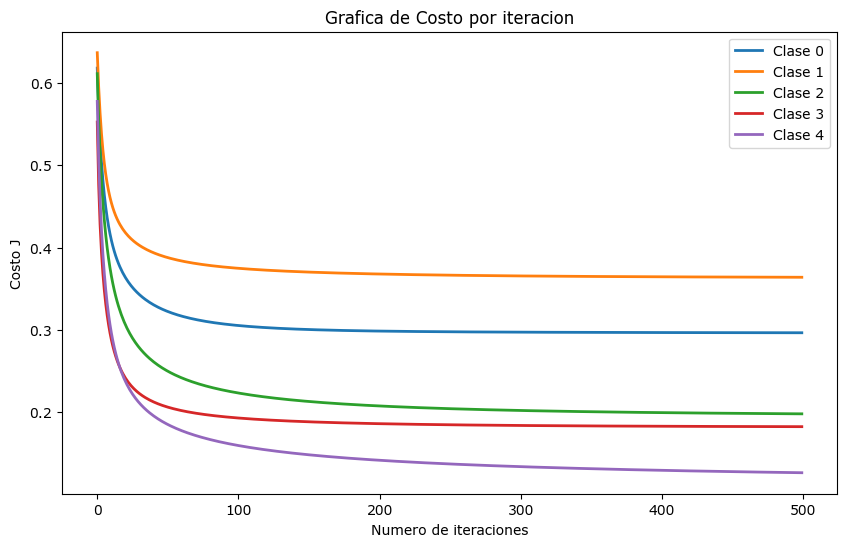


(Opcional) Parametros entrenados con OneVsAllOM (Scipy Optimize):
(5, 55)


In [34]:
def OneVsAllOM(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 50}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)
        all_theta[c] = res.x

    return all_theta

# Parametro de regularizacion
lambda_ = 0.1

print("Iniciando Entrenamiento con Descenso de Gradiente (Generando Grafica)...")
all_theta = OneVsAll(X, y, num_labels, lambda_)

print("\n(Opcional) Parametros entrenados con OneVsAllOM (Scipy Optimize):")
all_theta_OM = OneVsAllOM(X, y, num_labels, lambda_)
print(all_theta_OM.shape)

In [35]:
lambda_ = 0.1
all_theta = OneVsAllOM(X, y, num_labels, lambda_)
print(all_theta.shape)

(5, 55)


In [36]:
print(all_theta)

[[-3.38222790e+00  2.28215429e+00  2.10288942e-02 -8.49785263e-03
  -1.29026962e-01 -9.92400405e-02 -7.00098018e-02 -6.77920654e-03
   9.98353256e-03 -1.70316255e-02 -1.59763792e-01 -5.93012565e-02
  -8.06042165e-02 -8.28203113e-01 -2.43277972e+00  1.31358656e-02
  -4.76444064e-02 -1.34225397e-01 -5.70374765e-02 -3.55356722e-02
   5.28408469e-02  0.00000000e+00 -1.05531207e-02 -4.17694326e-02
  -8.05225085e-02 -6.84797224e-02 -5.71587633e-02 -7.35403368e-02
  -6.45142672e-02  0.00000000e+00 -4.67393246e-02 -6.02539545e-02
  -7.92507861e-02 -3.06832927e-02 -8.99431535e-02 -9.15037310e-02
  -1.87244379e-02 -6.26412221e-02 -7.30479845e-02 -5.22270776e-02
  -8.41956299e-02 -8.44334483e-02 -7.80889033e-02 -1.31756007e-02
  -1.13015603e-02 -1.56024792e-01 -1.70293911e-01 -2.28157004e-01
  -1.25747907e-01 -3.08044365e-01 -2.42097708e-01 -3.03906874e-01
  -5.59154885e-01 -6.73866342e-01 -5.29705721e-01]
 [-2.60340699e+00 -1.53005582e+00 -2.45790002e-02 -3.34400890e-02
   9.24273196e-02  1.0666

<a id="section3"></a>
#### Prediccion One-vs-all

Después de entrenar el clasificador de one-vs-all, se puede usarlo para predecir el dígito contenido en una imagen determinada. Para cada entrada, debe calcular la "probabilidad" de que pertenezca a cada clase utilizando los clasificadores de regresión logística entrenados.

In [37]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0];
    num_labels = all_theta.shape[0]
    p = np.zeros(m)
    
    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

Una vez que haya terminado, se llama a la función `predictOneVsAll` usando el valor aprendido de $\theta$. Debería apreciarse que la precisión del conjunto de entrenamiento es de aproximadamente 95,1% (es decir, clasifica correctamente el 95,1% de los ejemplos del conjunto de entrenamiento).

In [39]:
print(X.shape)
pred = predictOneVsAll(all_theta, X)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))
XPrueba = X[100:145, :].copy()
print(XPrueba.shape)
#print(np.ones((1)))
#print(XPrueba)
#p = np.zeros(1)
XPrueba = np.concatenate([np.ones((45, 1)), XPrueba], axis=1)
print(XPrueba.shape)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis = 1)
print(p)

# displayData(X[1002:1003, :])
print(y[100:145])

(45704, 54)
Precision del conjuto de entrenamiento: 81.83%
(45, 54)
(45, 55)
[3 2 2 3 3 0 4 3 4 2 2 2 0 2 4 3 3 2 4 4 0 3 0 3 2 2 2 3 3 3 2 0 1 0 1 4 4
 0 1 2 4 0 0 3 3]
[3 2 2 3 3 0 4 3 4 3 2 3 0 2 4 3 3 2 4 4 0 3 0 3 1 2 2 3 3 3 3 0 1 0 1 0 4
 0 1 2 0 0 4 3 3]


Evaluando con datos de prueba: (11426, 54)
Precision del conjunto de entrenamiento: 81.17%


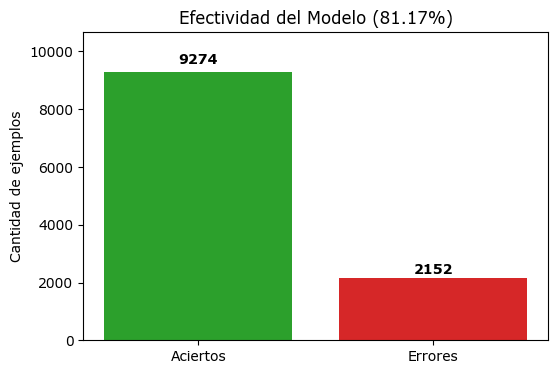

In [41]:
# Usamos el 20% de PRUEBA (X_test_norm) en lugar de un rango manual
print(f"Evaluando con datos de prueba: {X_test_norm.shape}")
pred = predictOneVsAll(all_theta, X_test_norm)

# Calculamos y mostramos la precisión final
precision = np.mean(pred == y_test) * 100
print('Precision del conjunto de entrenamiento: {:.2f}%'.format(precision))

# Grafica de precision (Efectividad del modelo)
aciertos = np.sum(pred == y_test)
errores = len(y_test) - aciertos

pyplot.figure(figsize=(6, 4))
barras = pyplot.bar(['Aciertos', 'Errores'], [aciertos, errores], color=['#2ca02c', '#d62728'])
pyplot.title(f'Efectividad del Modelo ({precision:.2f}%)')
pyplot.ylabel('Cantidad de ejemplos')

for barra in barras:
    yval = barra.get_height()
    pyplot.text(barra.get_x() + barra.get_width()/2, yval + (yval*0.02), int(yval), ha='center', va='bottom', fontweight='bold')

pyplot.ylim(0, max(aciertos, errores) * 1.15)
pyplot.show()